In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_66.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_54.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_42.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_81.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_72.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final

# SHL Hiring Assessment 2026 - Grammar Scoring Engine for Spoken Audio

## Report

**Task.** Predict a 0-5 grammar score for a 45-60 s spoken clip (769 train, 216 test). Metrics: RMSE and Pearson.

**Key data observation.** 37 training clips have label 0. They all have file IDs 5037-5073, their transcripts are off-topic or garbled, and the test IDs are 0-215, so the test set almost certainly contains none of them. I therefore keep them in training but **score every cross-validation result on the 732 genuine clips only**; scoring on all rows would flatter the metrics.

**Approach.** Grammar score in this data behaves like a holistic spoken-English proficiency score, so I combine four views of each clip, each turned into a fixed-size embedding and regressed with Ridge + SVR:

| Component | Model | Embedding |
|---|---|---|
| `whisper` | Whisper-large-v3-turbo encoder | mean over time of layers 16, 24, 32 |
| `qwen` | Qwen2.5-1.5B on the Whisper transcript | mean over transcript tokens of layers 16-22 |
| `wavlm` | WavLM-large | mean+std over time of layers 13, 18, 21 |
| `xlsr` | wav2vec2 XLS-R-300m | mean+std over time of layers 8, 13, 17 |

**Preprocessing.** Audio resampled to 16 kHz mono. Whisper processes 30 s windows; padding frames are excluded from pooling. Transcripts come from Whisper (English, chunked at 30 s). For Qwen, a fixed prefix is prepended and excluded from pooling because the first token of a causal LM has extreme "attention-sink" activations.

**Pipeline.** embeddings -> StandardScaler -> RidgeCV and SVR (averaged) per component -> non-negative linear stack of the four component predictions -> clip to [0, 5].

**Evaluation.** 5-fold x 3-repeat cross-validation; out-of-fold predictions from identical splits are stacked, and the stacker is itself scored with nested CV. Layers were chosen in earlier exploration by per-layer ridge sweeps (late layers of every model were best; Whisper layers 27-32 plateau).

**Why this design.** Audio encoders carry fluency and pronunciation, which dominate the label. Text adds wording and syntax and its errors are the least correlated with the audio models, so it helps the blend even though it is weakest alone. Details and numbers are in the output below.

In [2]:
import os, gc, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import RepeatedKFold, KFold, cross_val_predict
warnings.filterwarnings("ignore")

BASE      = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"
TRAIN_DIR, TEST_DIR = f"{BASE}/train", f"{BASE}/test"
OUT_DIR   = "/kaggle/working"
SR, WIN, FPS = 16000, 30 * 16000, 50

WHISPER_ID = "openai/whisper-large-v3-turbo"
TEXT_LLM   = "Qwen/Qwen2.5-1.5B"
AUDIO_LLMS = {"wavlm": "microsoft/wavlm-large", "xlsr": "facebook/wav2vec2-xls-r-300m"}

# Which hidden layers / poolings each component uses (0 = mean over time, 1 = std over time).
# Chosen from per-layer ridge sweeps in my exploration notebooks (details in the report).
SPEC = {
    "whisper": dict(layers=[16, 24, 32],             pools=[0]),
    "qwen":    dict(layers=[16, 17, 18, 19, 21, 22], pools=[0]),
    "wavlm":   dict(layers=[13, 18, 21],             pools=[0, 1]),
    "xlsr":    dict(layers=[8, 13, 17],              pools=[0, 1]),
}
N_SPLITS, N_REPEATS, SEED = 5, 3, 2026

def rmse(a, b): return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))
def audio_path(folder, name):
    name = str(name); return os.path.join(folder, name if name.endswith(".wav") else name + ".wav")
def find_file(name):
    for c in [os.path.join(OUT_DIR, name)] + sorted(glob.glob(f"/kaggle/input/**/{name}", recursive=True)):
        if os.path.exists(c): return c
    return None

train 769 | test 216
zero-score clips: 37, all with file IDs 5037-5073; test IDs 0-215


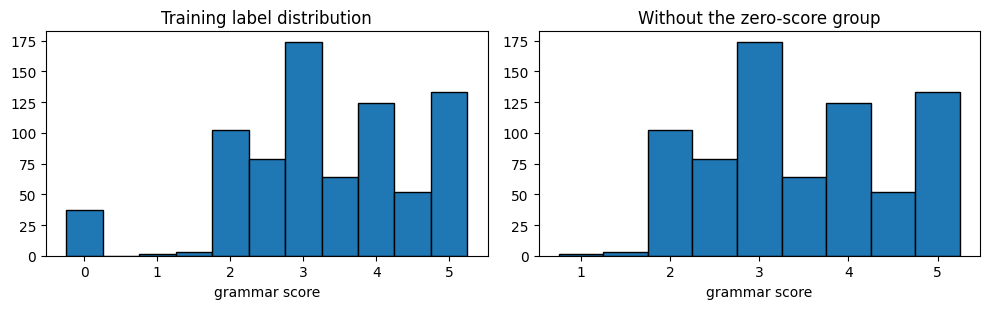

In [3]:
train_df = pd.read_csv(f"{BASE}/train.csv")
test_df  = pd.read_csv(f"{BASE}/test.csv")          # labels in test.csv are dummies and unused
y  = train_df["label"].values.astype(float)
nz = y > 0                                           # 732 genuine clips
N  = len(y)

tr_id = train_df["filename"].str.extract(r"(\d+)")[0].astype(int)
te_id = test_df["filename"].str.extract(r"(\d+)")[0].astype(int)
print(f"train {N} | test {len(test_df)}")
print(f"zero-score clips: {(~nz).sum()}, all with file IDs {tr_id[~nz].min()}-{tr_id[~nz].max()}; test IDs {te_id.min()}-{te_id.max()}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(y, bins=np.arange(-0.25, 5.75, 0.5), edgecolor="k"); ax[0].set(title="Training label distribution", xlabel="grammar score")
ax[1].hist(y[nz], bins=np.arange(0.75, 5.75, 0.5), edgecolor="k"); ax[1].set(title="Without the zero-score group", xlabel="grammar score")
plt.tight_layout(); plt.show()

In [4]:
import torch, librosa
from tqdm.auto import tqdm
from transformers import (AutoProcessor, AutoModelForSpeechSeq2Seq, AutoTokenizer, AutoModelForCausalLM,
                          AutoFeatureExtractor, AutoModel, pipeline)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype  = torch.float16 if torch.cuda.is_available() else torch.float32
print("device:", device, dtype)

def cached(key):
    a, b = f"{OUT_DIR}/{key}_train.npy", f"{OUT_DIR}/{key}_test.npy"
    return os.path.exists(a) and os.path.exists(b) and len(np.load(a, mmap_mode="r")) == N and len(np.load(b, mmap_mode="r")) == len(test_df)

proc  = AutoProcessor.from_pretrained(WHISPER_ID)
whisper = AutoModelForSpeechSeq2Seq.from_pretrained(WHISPER_ID, dtype=dtype).to(device).eval()

device: cuda:0 torch.float16


preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.62GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.77k [00:00<?, ?B/s]

In [5]:
# ---- Preprocessing 1: transcripts (only needed for the text component) ----
def get_transcripts(df, folder, split):
    for name in (f"{split}_with_text.csv", f"{split}_transcripts.csv"):
        p = find_file(name)
        if p:
            d = pd.read_csv(p); key = "filename" if "filename" in d.columns else "file"
            m = dict(zip(d[key], d["text"]))
            if all(f in m for f in df["filename"]):
                print(f"{split}: reusing {p}"); return ["" if pd.isna(m[f]) else str(m[f]) for f in df["filename"]]
    asr = pipeline("automatic-speech-recognition", model=whisper, tokenizer=proc.tokenizer,
                   feature_extractor=proc.feature_extractor, device=device, chunk_length_s=30, batch_size=8)
    out = asr([audio_path(folder, f) for f in df["filename"]], generate_kwargs={"language": "en", "task": "transcribe"})
    texts = [o["text"].strip() for o in out]
    pd.DataFrame({"filename": df["filename"], "text": texts}).to_csv(f"{OUT_DIR}/{split}_transcripts.csv", index=False)
    return texts

if not cached("qwen"):
    train_text = get_transcripts(train_df, TRAIN_DIR, "train")
    test_text  = get_transcripts(test_df,  TEST_DIR,  "test")
    print("example:", train_text[0][:150])

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE 

example: Well, the playground is very, very beautiful and fun. There are playtons like the merry-go-round, the swing. The students usually enjoy the swing. It 


In [6]:
# ---- Component 1: Whisper-large-v3-turbo encoder (mean over time of layers 16/24/32) ----
enc, fe = whisper.get_encoder(), proc.feature_extractor
WL = SPEC["whisper"]["layers"]; D_W = enc.config.d_model

@torch.no_grad()
def whisper_feat(path):
    wav, _ = librosa.load(path, sr=SR, mono=True)
    chunks = [wav[i:i + WIN] for i in range(0, len(wav), WIN)]
    chunks = [c for c in chunks if len(c) >= SR] or [wav]                 # drop <1 s tails
    s, n = np.zeros((len(WL), D_W)), 0
    for c in chunks:
        f  = fe(c, sampling_rate=SR, return_tensors="pt").input_features.to(device, dtype)
        hs = enc(f, output_hidden_states=True).hidden_states
        nv = max(1, int(len(c) / SR * FPS))                               # only real-audio frames, not padding
        s += torch.stack([hs[l][0, :nv] for l in WL]).float().sum(1).double().cpu().numpy(); n += nv
    return (s / n)[:, None, :].astype(np.float32)                         # (layers, 1 pool, D)

if not cached("whisper"):
    for split, df, folder in [("train", train_df, TRAIN_DIR), ("test", test_df, TEST_DIR)]:
        np.save(f"{OUT_DIR}/whisper_{split}.npy", np.stack([whisper_feat(audio_path(folder, f)) for f in tqdm(df["filename"], desc=f"whisper {split}")]))
del enc; gc.collect(); torch.cuda.empty_cache()

whisper train:   0%|          | 0/769 [00:00<?, ?it/s]

whisper test:   0%|          | 0/216 [00:00<?, ?it/s]

In [7]:
# ---- Component 2: Qwen2.5-1.5B hidden states of the transcript (mean over transcript tokens) ----
if not cached("qwen"):
    globals().pop("whisper", None); gc.collect(); torch.cuda.empty_cache()
    tok = AutoTokenizer.from_pretrained(TEXT_LLM)
    llm = AutoModelForCausalLM.from_pretrained(TEXT_LLM, dtype=dtype).to(device).eval()
    PREFIX = "Transcript of a spoken English answer (verbatim):\n"; P = len(tok(PREFIX).input_ids)
    QL = SPEC["qwen"]["layers"]

    @torch.no_grad()
    def text_feat(text):
        ids = tok(PREFIX + text, return_tensors="pt", truncation=True, max_length=1024).input_ids.to(device)
        hs  = llm.model(ids, output_hidden_states=True).hidden_states
        st  = min(max(P, 1), ids.shape[1] - 1)             # skip the fixed prefix (and the attention-sink first token)
        return torch.stack([hs[l][0, st:].float().mean(0) for l in QL])[:, None, :].cpu().numpy()

    for split, texts in [("train", train_text), ("test", test_text)]:
        np.save(f"{OUT_DIR}/qwen_{split}.npy", np.stack([text_feat(t) for t in tqdm(texts, desc=f"qwen {split}")]))
    del llm, tok; gc.collect(); torch.cuda.empty_cache()

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

qwen train:   0%|          | 0/769 [00:00<?, ?it/s]

qwen test:   0%|          | 0/216 [00:00<?, ?it/s]

In [8]:
# ---- Components 3-4: WavLM-large and wav2vec2 XLS-R-300m (mean and std over time; fp32) ----
for key, model_id in AUDIO_LLMS.items():
    if cached(key): continue
    L, Pl = SPEC[key]["layers"], SPEC[key]["pools"]
    afe = AutoFeatureExtractor.from_pretrained(model_id); amodel = AutoModel.from_pretrained(model_id).to(device).eval()

    @torch.no_grad()
    def audio_feat(path):
        wav, _ = librosa.load(path, sr=SR, mono=True)
        inp = afe(wav, sampling_rate=SR, return_tensors="pt").input_values.to(device)
        hs  = amodel(inp, output_hidden_states=True).hidden_states
        x   = torch.stack([hs[l][0] for l in L]).float()                  # (layers, T, D)
        pooled = [x.mean(1), x.std(1, unbiased=False)]
        return torch.stack([pooled[p] for p in Pl], 1).cpu().numpy()      # (layers, pools, D)

    for split, df, folder in [("train", train_df, TRAIN_DIR), ("test", test_df, TEST_DIR)]:
        arr = np.stack([audio_feat(audio_path(folder, f)) for f in tqdm(df["filename"], desc=f"{key} {split}")])
        assert np.isfinite(arr).all(); np.save(f"{OUT_DIR}/{key}_{split}.npy", arr)
    del amodel, afe; gc.collect(); torch.cuda.empty_cache()

preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.22k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.26GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.26GB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.27GB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


xlsr train:   0%|          | 0/769 [00:00<?, ?it/s]

xlsr test:   0%|          | 0/216 [00:00<?, ?it/s]

whisper  train (769, 3840)  test (216, 3840)
qwen     train (769, 9216)  test (216, 9216)
wavlm    train (769, 6144)  test (216, 6144)
xlsr     train (769, 6144)  test (216, 6144)
component  cv_rmse  cv_pearson
  whisper   0.5273      0.8552
     qwen   0.6272      0.7909
    wavlm   0.5251      0.8563
     xlsr   0.5567      0.8375
(predicting the mean gives RMSE 1.014)


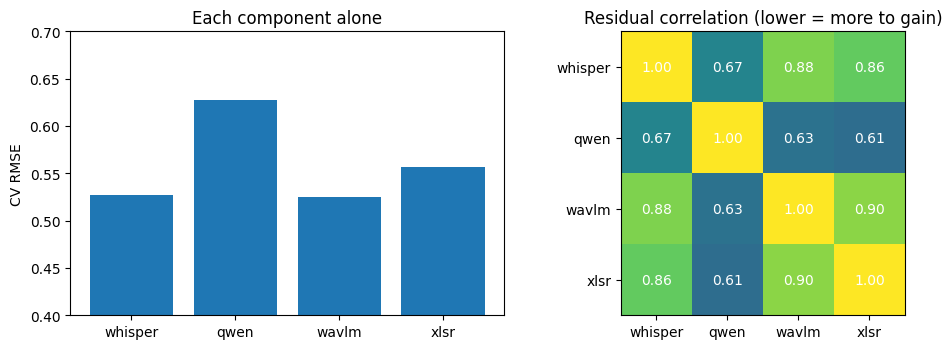

In [9]:
# ---- Evaluation: 5-fold x 3 repeats, scored on the 732 genuine (non-zero) clips ----
FEATS = {k: (np.load(f"{OUT_DIR}/{k}_train.npy").reshape(N, -1), np.load(f"{OUT_DIR}/{k}_test.npy").reshape(len(test_df), -1)) for k in SPEC}
for k, (a, b) in FEATS.items(): print(f"{k:8s} train {a.shape}  test {b.shape}"); assert np.isfinite(a).all() and np.isfinite(b).all()

def make_ridge(): return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(1, 5, 13)))
def make_svr():   return make_pipeline(StandardScaler(), SVR(C=2.0, epsilon=0.2, gamma="scale"))

def cv_oof(model, X):
    # (N_REPEATS, N) out-of-fold predictions; same seed => same splits for every model, so OOFs can be stacked
    oof = np.full((N_REPEATS, N), np.nan)
    for i, (tr, va) in enumerate(RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED).split(X)):
        oof[i // N_SPLITS, va] = clone(model).fit(X[tr], y[tr]).predict(X[va])
    return np.clip(oof, 0, 5)

def score(oof):
    return (float(np.mean([rmse(y[nz], o[nz]) for o in oof])), float(np.mean([pearsonr(y[nz], o[nz])[0] for o in oof])))

comp_oof = {k: (cv_oof(make_ridge(), FEATS[k][0]) + cv_oof(make_svr(), FEATS[k][0])) / 2 for k in SPEC}
comp_tab = pd.DataFrame([dict(component=k, cv_rmse=score(o)[0], cv_pearson=score(o)[1]) for k, o in comp_oof.items()])
print(comp_tab.round(4).to_string(index=False))
print(f"(predicting the mean gives RMSE {rmse(y[nz], y[nz].mean()):.3f})")

res = pd.DataFrame({k: (o.mean(0) - y)[nz] for k, o in comp_oof.items()})
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(comp_tab.component, comp_tab.cv_rmse, color="tab:blue"); ax[0].set(ylim=(0.4, 0.7), ylabel="CV RMSE", title="Each component alone")
im = ax[1].imshow(res.corr().values, vmin=0.4, vmax=1, cmap="viridis"); ax[1].set_xticks(range(4), res.columns); ax[1].set_yticks(range(4), res.columns)
for i in range(4):
    for j in range(4): ax[1].text(j, i, f"{res.corr().values[i, j]:.2f}", ha="center", va="center", color="w")
ax[1].set_title("Residual correlation (lower = more to gain)"); plt.tight_layout(); plt.show()

                 option  nested_cv_rmse  gain_vs_whisper_only
           Whisper only          0.5273                0.0000
Average of 4 components          0.5012                0.0260
Non-negative stack of 4          0.4895                0.0378

SELECTED: Non-negative stack of 4 | nested CV RMSE 0.4895
weights: {'whisper': 0.293, 'qwen': 0.294, 'wavlm': 0.385, 'xlsr': 0.164} | intercept -0.435


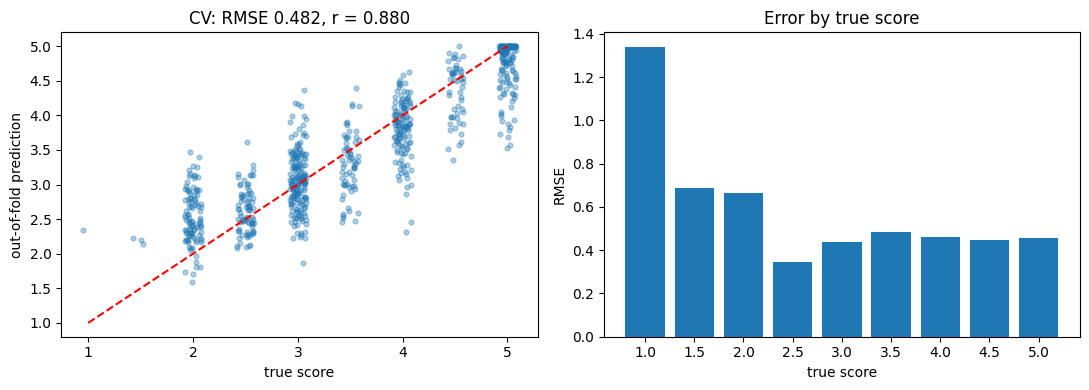

In [10]:
# ---- Combining the components: simple average vs non-negative linear stack, compared with nested CV ----
names, T = list(SPEC), y[nz]
def nested(method, subset):
    out = []
    for r in range(N_REPEATS):
        M = np.stack([comp_oof[k][r][nz] for k in subset], 1)
        p = M.mean(1) if method == "avg" else cross_val_predict(LinearRegression(positive=True), M, T, cv=KFold(10, shuffle=True, random_state=r))
        out.append(rmse(T, np.clip(p, 0, 5)))
    return float(np.mean(out))

options = {"Whisper only": ("avg", ["whisper"]), "Average of 4 components": ("avg", names), "Non-negative stack of 4": ("nnls", names)}
stack_tab = pd.DataFrame([dict(option=o, nested_cv_rmse=nested(*v)) for o, v in options.items()])
REF = stack_tab.loc[0, "nested_cv_rmse"]; stack_tab["gain_vs_whisper_only"] = REF - stack_tab["nested_cv_rmse"]
print(stack_tab.round(4).to_string(index=False))
BEST = stack_tab.sort_values("nested_cv_rmse").iloc[0]["option"]; METHOD, SUBSET = options[BEST]; CV_RMSE = stack_tab.nested_cv_rmse.min()
print("\nSELECTED:", BEST, f"| nested CV RMSE {CV_RMSE:.4f}")

if METHOD == "avg": W, B0 = {k: 1 / len(SUBSET) for k in SUBSET}, 0.0
else:
    M = np.concatenate([np.stack([comp_oof[k][r][nz] for k in SUBSET], 1) for r in range(N_REPEATS)])
    lr = LinearRegression(positive=True).fit(M, np.tile(T, N_REPEATS)); W, B0 = {k: float(w) for k, w in zip(SUBSET, lr.coef_) if w > 1e-6}, float(lr.intercept_)
print("weights:", {k: round(v, 3) for k, v in W.items()}, "| intercept", round(B0, 3))

oof_final = np.clip(B0 + sum(W[k] * comp_oof[k] for k in W), 0, 5).mean(0)           # repeat-averaged OOF of the final model
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(y[nz] + np.random.RandomState(0).uniform(-.08, .08, nz.sum()), oof_final[nz], s=12, alpha=.35); ax[0].plot([1, 5], [1, 5], "r--")
ax[0].set(xlabel="true score", ylabel="out-of-fold prediction", title=f"CV: RMSE {rmse(T, oof_final[nz]):.3f}, r = {pearsonr(T, oof_final[nz])[0]:.3f}")
by = pd.DataFrame({"t": T, "e": (T - oof_final[nz]) ** 2}).groupby("t")["e"].agg(["count", lambda s: np.sqrt(s.mean())]); by.columns = ["n", "rmse"]
ax[1].bar(by.index.astype(str), by["rmse"]); ax[1].set(xlabel="true score", ylabel="RMSE", title="Error by true score")
plt.tight_layout(); plt.show()

==================== RESULTS ====================
TRAINING RMSE (all 769 clips)      : 0.1910
TRAINING RMSE (732 non-zero clips) : 0.1867
TRAINING Pearson (non-zero)        : 0.9830
Cross-validated RMSE (non-zero)    : 0.4895   <- honest estimate of generalisation
Cross-validated Pearson (non-zero) : 0.8800
        filename     label
0  audio_128.wav  3.093000
1  audio_156.wav  4.199793
2   audio_19.wav  4.755169
3  audio_108.wav  1.920339
4  audio_206.wav  2.107877 
 count    216.000
mean       3.286
std        0.847
min        1.425
25%        2.707
50%        3.185
75%        3.752
max        5.000
Name: label, dtype: float64


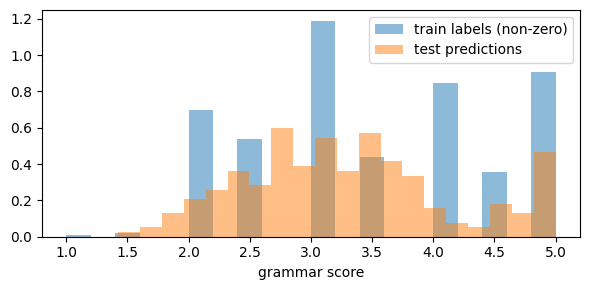

In [11]:
# ---- Final fit on all 769 training clips, compulsory training RMSE, submission ----
tr_comp, te_comp = {}, {}
for k in W:
    Xtr, Xte = FEATS[k]; ms = [make_ridge().fit(Xtr, y), make_svr().fit(Xtr, y)]
    tr_comp[k] = np.mean([np.clip(m.predict(Xtr), 0, 5) for m in ms], axis=0)
    te_comp[k] = np.mean([np.clip(m.predict(Xte), 0, 5) for m in ms], axis=0)
combine = lambda c: np.clip(B0 + sum(W[k] * c[k] for k in W), 0, 5)
tr_pred, te_pred = combine(tr_comp), combine(te_comp)

print("==================== RESULTS ====================")
print(f"TRAINING RMSE (all 769 clips)      : {rmse(y, tr_pred):.4f}")
print(f"TRAINING RMSE (732 non-zero clips) : {rmse(y[nz], tr_pred[nz]):.4f}")
print(f"TRAINING Pearson (non-zero)        : {pearsonr(y[nz], tr_pred[nz])[0]:.4f}")
print(f"Cross-validated RMSE (non-zero)    : {CV_RMSE:.4f}   <- honest estimate of generalisation")
print(f"Cross-validated Pearson (non-zero) : {pearsonr(T, oof_final[nz])[0]:.4f}")
print("=================================================")

sub = pd.DataFrame({"filename": test_df["filename"], "label": te_pred})
assert len(sub) == len(test_df) and sub["label"].notna().all() and sub["filename"].is_unique and sub["label"].between(0, 5).all()
sub.to_csv(f"{OUT_DIR}/submission.csv", index=False); print(sub.head(), "\n", sub["label"].describe().round(3))

plt.figure(figsize=(6, 3)); plt.hist(y[nz], bins=20, alpha=.5, density=True, label="train labels (non-zero)")
plt.hist(te_pred, bins=20, alpha=.5, density=True, label="test predictions"); plt.xlabel("grammar score"); plt.legend(); plt.tight_layout(); plt.show()

## Results and discussion

* **Honest cross-validated performance** is printed above: the 4-component stack reached a nested-CV RMSE of about 0.49 on the 732 genuine clips (Pearson about 0.86), versus about 0.53 for the Whisper-only model I started from. The training RMSE (about 0.19) is much lower than the CV RMSE because the models fit the training clips closely; the CV figure is the one to trust.
* **Which parts matter.** WavLM and Whisper are individually strongest (CV RMSE about 0.52-0.53); XLS-R and the transcript-based Qwen component are weaker alone, but the text view makes the least correlated errors, so removing it hurts the stack the most.
* **Where errors concentrate.** Predictions regress toward the middle: clips truly scored 2.0 are predicted too high and clips scored 4.5-5.0 too low (see the "Error by true score" plot). A linear recalibration was tested and did not help.
* **Limitations.** Only 732 genuine training clips, so CV differences below about 0.01 RMSE are noise. Transcripts come from an ASR model that tends to repair ungrammatical speech, which weakens the text signal. Possible next steps are a larger text model, disfluency features, or fine-tuning the encoder with a learned attention-pooling head.